# Mushroom Classification ML
Source: https://www.kaggle.com/datasets/zedsden/mushroom-classification-dataset

In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import time
import torch
import torch.nn as nn
import torch.optim as optim
import gc 

from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split  
from sklearn.metrics import precision_score, recall_score, f1_score

In [2]:
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
print("Memory cleared at start")

Memory cleared at start


# Load the dataset cleaned_mushroom_dataset1.csv

#### Further clean the dataset
- more feature engineering -> data cleaning and feature standardization before modeling.

1. Exploration of the dataset1 again after de-duplication
2. 

In [3]:
# 1. Load the cleaned dataset
df = pd.read_csv('cleaned_mushroom_dataset1.csv')

In [4]:
df.shape

(94631, 12)

In [5]:
df.head(10)

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species,phash
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,abb9d4a0aae5c4d4
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,a581b66e5c2d6b32
2,Classes/conditionally_edible/horn_of_plenty/14...,3,14,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,d8f40799f31ea870
3,Classes/conditionally_edible/horn_of_plenty/12...,3,12,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,a8a8e950d4af3f58
4,Classes/conditionally_edible/horn_of_plenty/13...,3,13,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,8e86638cdcad5bd0
5,Classes/conditionally_edible/horn_of_plenty/11...,3,11,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,a0b2cf41e0afde0e
6,Classes/conditionally_edible/horn_of_plenty/10...,3,10,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,cde6d0c836cb07c6
7,Classes/conditionally_edible/horn_of_plenty/4.png,3,4,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,88bd470f603c3de3
8,Classes/conditionally_edible/horn_of_plenty/5.png,3,5,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,a693018e7926aeee
9,Classes/conditionally_edible/horn_of_plenty/7.png,3,7,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,bf8991d1c7d2a4c8


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94631 entries, 0 to 94630
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   file_path     94631 non-null  object 
 1   depth         94631 non-null  int64  
 2   file_name     94631 non-null  object 
 3   file_ext      94631 non-null  object 
 4   width         94631 non-null  int64  
 5   height        94631 non-null  int64  
 6   aspect_ratio  94631 non-null  float64
 7   megapixels    94631 non-null  float64
 8   orientation   94631 non-null  object 
 9   class         94631 non-null  object 
 10  species       94631 non-null  object 
 11  phash         94631 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 8.7+ MB


In [7]:
df.describe()

,depth,width,height,aspect_ratio,megapixels
count,94631.000000,94631.000000,94631.000000,94631.000000,94631.000000
mean,3.058015,442.145650,422.347370,1.098890,0.192946
std,0.233773,141.794657,114.074508,0.355833,0.100622
min,3.000000,90.000000,90.000000,0.252000,0.008100
25%,3.000000,375.000000,368.000000,0.750000,0.166500
50%,3.000000,500.000000,500.000000,1.070664,0.187500
75%,3.000000,500.000000,500.000000,1.333333,0.187500
max,4.000000,1280.000000,1024.000000,4.385965,1.303552


In [8]:
len(df)

94631

In [9]:
df['class'].nunique()

4

In [10]:
df['species'].nunique()

570

In [11]:
df['file_ext'].nunique()

4

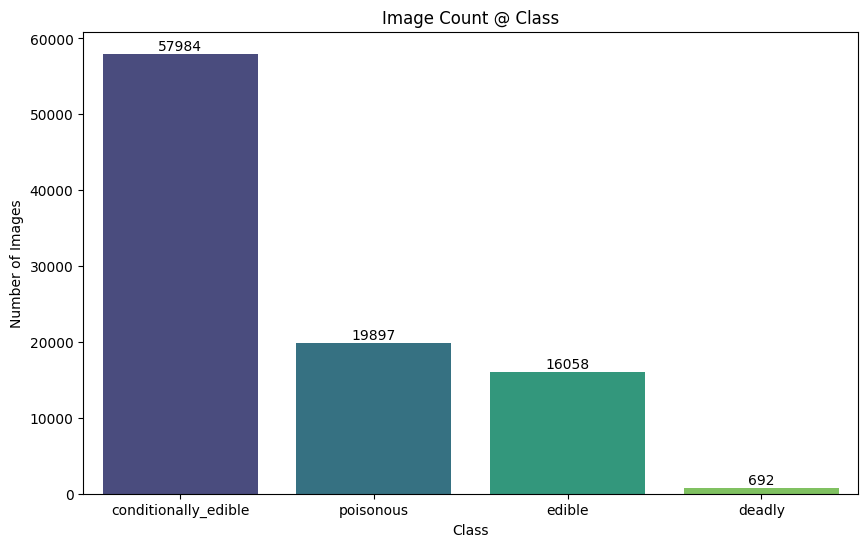

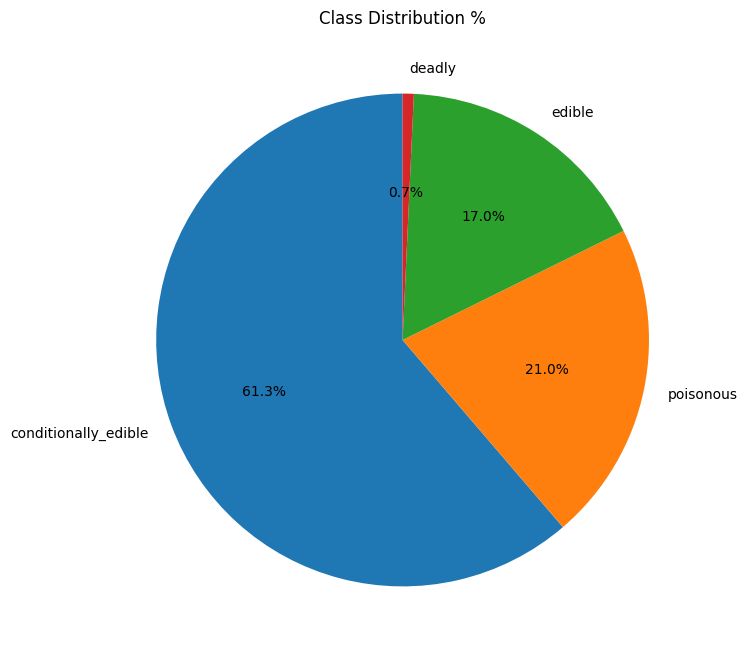

In [12]:
class_counts = df['class'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis', legend=False)
plt.title('Image Count @ Class')
plt.ylabel('Number of Images')
plt.xlabel('Class')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 500, str(v), ha='center')
plt.show()

# Pie chart for proportions
plt.figure(figsize=(8, 8))
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution %')
plt.show()

In [13]:
species_per_class = df.groupby('class')['species'].nunique()
print("Unique Species per Class:\n", species_per_class)

Unique Species per Class:
 class
conditionally_edible    175
deadly                   36
edible                  154
poisonous               213
Name: species, dtype: int64


In [14]:
images_per_class_top = df.groupby(['class', 'species']).size().groupby('class').nlargest(5)
print("\nTop 5 Species per Class by Image Count:\n", images_per_class_top)


Top 5 Species per Class by Image Count:
 class                 class                 species              
conditionally_edible  conditionally_edible  Fomes fomentarius        5246
                                            Fomitopsis pinicola      5090
                                            Parmelia sulcata         2643
                                            Laetiporus sulphureus    2296
                                            Hypogymnia physodes      2159
deadly                deadly                Amanita_arocheae           38
                                            Galerina_marginata         37
                                            Paxillus_involutus         34
                                            Lepiota_subincarnata       32
                                            Cortinarius_splendens      31
edible                edible                Cerioporus squamosus     1518
                                            Coprinus comatus         1303
    

In [15]:
print("Species with ≤ 10 images:")
print(df['species'].value_counts()[lambda x: x <= 10].sort_values())

print("\nSpecies with ≥ 1000 images per class:")
print(df.groupby('class')['species'].value_counts().loc[lambda x: x >= 1000])

Species with ≤ 10 images:
species
truffles                    4
devils_bolete               8
deadly_webcap               8
orange_birch_bolete         8
cinnamon_bracket            9
golden_bootleg             10
hoof_fungus                10
Amanita_virosa             10
oak_polypore               10
cedarwood_waxcap           10
leccinum_albostipitatum    10
smoky_bracket              10
rooting_shank              10
Boletus_pulcherrimus       10
Name: count, dtype: int64

Species with ≥ 1000 images per class:
class                 species              
conditionally_edible  Fomes fomentarius        5246
                      Fomitopsis pinicola      5090
                      Parmelia sulcata         2643
                      Laetiporus sulphureus    2296
                      Hypogymnia physodes      2159
                      Leccinum scabrum         1691
                      Fomitopsis betulina      1585
                      Lactarius                1498
                     

In [16]:
df.groupby('class')[['width', 'height', 'megapixels']].agg(['mean','min','max','count'])

width                        height             \
                            mean  min   max  count        mean  min   max   
class                                                                       
conditionally_edible  475.742463  100  1280  57984  446.630122  100  1024   
deadly                203.919075  100   387    692  175.578035  100   345   
edible                404.116079   90   512  16058  395.755200   90   512   
poisonous             383.214857   94   512  19897  381.626175   90   512   

                            megapixels                             
                      count       mean       min       max  count  
class                                                              
conditionally_edible  57984   0.215825  0.010000  1.303552  57984  
deadly                  692   0.038272  0.010000  0.050625    692  
edible                16058   0.164882  0.008100  0.262144  16058  
poisonous             19897   0.154298  0.008742  0.262144  19897

### Check the number of files were skipped (i.e. could not be successfully read or processed)

1. Check missing values.
2. Check duplicate rows.
3. Check duplicate pHash values - potential duplicate images.
4. Check inconsistent species naming - underscores vs spaces, etc.
5. Check zero or negative dimensions.
6. Check class balance statistics.
7. Check species distribution per class.
8. Check any naming inconsistencies

In [17]:
# check the dataframe for various inconsistencies

print("- MISSING VALUES CHECK")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("\n- DUPLICATE ROWS CHECK")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

print("\n- DUPLICATE pHASH CHECK")
duplicate_phash = df['phash'].duplicated().sum()
print(f"Number of duplicate pHash values: {duplicate_phash}")

print("\n- SPECIES NAMING PATTERNS CHECK")
species_with_underscores = df[df['species'].str.contains('_', na=False)]['species'].nunique()
species_with_spaces = df[df['species'].str.contains(' ', na=False)]['species'].nunique()
print(f"Species with underscores: {species_with_underscores}")
print(f"Species with spaces: {species_with_spaces}")

print("\n- IMAGE DIMENSION CHECKS")
invalid_width = df[df['width'] <= 0].shape[0]
invalid_height = df[df['height'] <= 0].shape[0]
print(f"Rows with invalid width (≤0): {invalid_width}")
print(f"Rows with invalid height (≤0): {invalid_height}")

print("\n- CLASS BALANCE SUMMARY")
class_stats = df['class'].value_counts()
print(f"Most frequent class: {class_stats.index[0]} ({class_stats.values[0]} images)")
print(f"Least frequent class: {class_stats.index[-1]} ({class_stats.values[-1]} images)")

print("\n- SPECIES DISTRIBUTION PER CLASS")
species_per_class = df.groupby('class')['species'].nunique()
print(species_per_class)

- MISSING VALUES CHECK
Series([], dtype: int64)

- DUPLICATE ROWS CHECK
Number of duplicate rows: 0

- DUPLICATE pHASH CHECK
Number of duplicate pHash values: 0

- SPECIES NAMING PATTERNS CHECK
Species with underscores: 447
Species with spaces: 100

- IMAGE DIMENSION CHECKS
Rows with invalid width (≤0): 0
Rows with invalid height (≤0): 0

- CLASS BALANCE SUMMARY
Most frequent class: conditionally_edible (57984 images)
Least frequent class: deadly (692 images)

- SPECIES DISTRIBUTION PER CLASS
class
conditionally_edible    175
deadly                   36
edible                  154
poisonous               213
Name: species, dtype: int64


In [18]:
# regex patterns 
leading_trailing = r'^\s|\s$'
multiple_spaces = r'\s{2,}'
special_chars = r'[^a-zA-Z0-9\s-]'

# use the variables in f-strings
print(f"- Case variations: {df['species'].str.lower().duplicated().any()}")
print(f"- Has leading/trailing spaces: {df['species'].str.contains(leading_trailing, regex=True).any()}")
print(f"- Has multiple spaces: {df['species'].str.contains(multiple_spaces, regex=True).any()}")
print(f"- Has underscores: {df['species'].str.contains('_').any()}")
print(f"- Has special characters: {df['species'].str.contains(special_chars, regex=True).any()}")
print(f"- Species in multiple classes: {(df.groupby('species')['class'].nunique() > 1).any()}")

- Case variations: True
- Has leading/trailing spaces: False
- Has multiple spaces: False
- Has underscores: True
- Has special characters: True
- Species in multiple classes: True


In [19]:
print(f"Unique species BEFORE: {df['species'].nunique()}")

# fix species names - case, underscores, spaces, special chars
df['species'] = df['species'].str.strip().str.replace('_', ' ').str.replace(r'[^a-zA-Z0-9\s-]', '', regex=True).str.title().str.replace(r'\s+', ' ', regex=True).str.strip()

# fix class inconsistencies - assign most common class to each species
df['class'] = df.groupby('species')['class'].transform(lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0])

print(f"Unique species AFTER: {df['species'].nunique()}")

Unique species BEFORE: 570
Unique species AFTER: 542


In [20]:
df.shape

(94631, 12)

In [21]:
df['class'].value_counts()

class
conditionally_edible    58196
poisonous               19854
edible                  15933
deadly                    648
Name: count, dtype: int64

In [22]:
df.groupby('class')['species'].nunique()

class
conditionally_edible    169
deadly                   28
edible                  143
poisonous               202
Name: species, dtype: int64

In [23]:
df.head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species,phash
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,abb9d4a0aae5c4d4
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,a581b66e5c2d6b32
2,Classes/conditionally_edible/horn_of_plenty/14...,3,14,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,d8f40799f31ea870
3,Classes/conditionally_edible/horn_of_plenty/12...,3,12,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,a8a8e950d4af3f58
4,Classes/conditionally_edible/horn_of_plenty/13...,3,13,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,8e86638cdcad5bd0


In [24]:
# Final dataset preparation
print("*****  TRAINING DATASET   *****")

# 1. Check for duplicates after cleaning
print("1. Checking for duplicates...")
duplicates = df.duplicated(subset=['file_path', 'species', 'class'], keep=False)
if duplicates.any():
    print(f"   Found {duplicates.sum()} potential duplicates")
    # Keep highest resolution version
    df = df.sort_values('num_pixels', ascending=False)
    df = df.drop_duplicates(subset=['file_path', 'species_grouped', 'class'], keep='first')

# 2. Verify class distribution
print("\n2. Class distribution:")
print(df['class'].value_counts())

# 3. Verify species distribution per class
print("\n3. Species per class:")
for class_name in df['class'].unique():
    class_species = df[df['class'] == class_name]['species'].nunique()
    print(f"   {class_name}: {class_species} species")

# 4. Save cleaned dataset
df.to_csv('training_dataset.csv', index=False)  # Changed from cleaned_data to df
print(f"\nSaved cleaned dataset: {len(df)} samples")  # Changed from cleaned_data to df
print(f"Columns: {list(df.columns)}")  # Changed from cleaned_data to df

*****  TRAINING DATASET   *****
1. Checking for duplicates...

2. Class distribution:
class
conditionally_edible    58196
poisonous               19854
edible                  15933
deadly                    648
Name: count, dtype: int64

3. Species per class:
   conditionally_edible: 169 species
   poisonous: 202 species
   edible: 143 species
   deadly: 28 species

Saved cleaned dataset: 94631 samples
Columns: ['file_path', 'depth', 'file_name', 'file_ext', 'width', 'height', 'aspect_ratio', 'megapixels', 'orientation', 'class', 'species', 'phash']


# Setting up the Models - Balance the dataset before running the models

In [25]:
df.head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species,phash
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,abb9d4a0aae5c4d4
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,a581b66e5c2d6b32
2,Classes/conditionally_edible/horn_of_plenty/14...,3,14,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,d8f40799f31ea870
3,Classes/conditionally_edible/horn_of_plenty/12...,3,12,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,a8a8e950d4af3f58
4,Classes/conditionally_edible/horn_of_plenty/13...,3,13,png,512,512,1.0,0.262144,square,conditionally_edible,Horn Of Plenty,8e86638cdcad5bd0


# Model Setup - get the dataset ready by getting samples from each species of each class

In [26]:
target = 1000
balanced_dfs = []

for class_name in df['class'].unique():
    class_df = df[df['class'] == class_name]
    
    if class_name == 'deadly':
        balanced_dfs.append(class_df)
        print(f"{class_name}: {len(class_df)} images")
    else:
        n_species = class_df['species'].nunique()
        base = target // n_species
        remainder = target % n_species
        
        sampled_dfs = []
        shortfall = 0
        
        for i, species in enumerate(class_df['species'].unique()):
            species_df = class_df[class_df['species'] == species]
            take = base + (1 if i < remainder else 0)
            
            if len(species_df) >= take:
                sampled_dfs.append(species_df.sample(n=take, random_state=42))
            else:
                sampled_dfs.append(species_df.copy())
                shortfall += take - len(species_df)
        
        if shortfall > 0:
            for i, species in enumerate(class_df['species'].unique()):
                if shortfall <= 0: break
                species_df = class_df[class_df['species'] == species]
                available = len(species_df) - len(sampled_dfs[i])
                if available > 0:
                    take_extra = min(shortfall, available)
                    remaining = species_df.drop(sampled_dfs[i].index)
                    extra = remaining.sample(n=take_extra, random_state=42)
                    sampled_dfs[i] = pd.concat([sampled_dfs[i], extra])
                    shortfall -= take_extra
        
        sampled = pd.concat(sampled_dfs, ignore_index=True)
        balanced_dfs.append(sampled)
        print(f"{class_name}: {len(sampled)}/{target} images")

df_balanced = pd.concat(balanced_dfs, ignore_index=True)
print(f"\n✅ Balanced dataset: {len(df_balanced)} images")
print(df_balanced['class'].value_counts())

conditionally_edible: 1000/1000 images
poisonous: 1000/1000 images
edible: 1000/1000 images
deadly: 648 images

✅ Balanced dataset: 3648 images
class
conditionally_edible    1000
poisonous               1000
edible                  1000
deadly                   648
Name: count, dtype: int64


In [27]:
df_balanced.to_csv('balanced_training_dataset.csv', index=False)

print(f"\nSaved: mushroom_dataset_balanced.csv")
print(f"\nSUMMARY: {len(df_balanced)} images, {df_balanced['class'].nunique()} classes, {df_balanced['species'].nunique()} species")


Saved: mushroom_dataset_balanced.csv

SUMMARY: 3648 images, 4 classes, 542 species


In [28]:
print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")

if torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.set_num_threads(4)
    torch.mps.empty_cache()
else:
    device = torch.device("cpu")
    print("MPS not available, using CPU")

print(f"Using device: {device}")

PyTorch version: 2.7.0
MPS available: True
Using device: mps


# Training / Validation / Testing = 80 / 10 / 10

### Reuse printing functions

In [29]:
def print_header(title):
    print(f"\n{'='*60}\n{title}\n{'='*60}")

def print_subheader(title):
    print(f"\n{title}\n{'-'*40}")

def print_metrics_table(epoch, train_loss, train_acc, val_loss, val_acc, val_f1, time):
    if epoch == 1:
        print(f"\n{'Epoch':<6} {'TRAIN Loss':<12} {'TRAIN Acc':<12} {'VAL Loss':<12} {'VAL Acc':<12} {'VAL F1':<12} {'Time':<10}")
        print(f"{'-'*80}")
    print(f"{epoch:<6} {train_loss:<12.4f} {train_acc:<11.2f} {val_loss:<12.4f} {val_acc:<11.2f} {val_f1:<11.2f} {time:<10.1f}")

def print_final_metrics(test_acc, test_precision, test_recall, test_f1):
    print(f"\n{'📊 FINAL TEST METRICS':^60}")
    print(f"{'-'*60}")
    print(f"{'Metric':<20} {'Score':<10}")
    print(f"{'-'*60}")
    print(f"{'Accuracy':<20} {test_acc:<10.2f}")
    print(f"{'Precision':<20} {test_precision:<10.2f}")
    print(f"{'Recall':<20} {test_recall:<10.2f}")
    print(f"{'F1 Score':<20} {test_f1:<10.2f}")
    print(f"{'-'*60}")

def print_class_distribution(df, title):
    print(f"\n{title}:")
    print(df['class'].value_counts().to_string())

def print_dataset_summary(train_df, val_df, test_df):
    print(f"\n✅ Train: {len(train_df)} images")
    print(f"✅ Val: {len(val_df)} images")
    print(f"✅ Test: {len(test_df)} images")

# RESNET18 TRAINING

# Training 

1. Split the balanced dataset. go 80 / 10/ 10
2. Data Augmentation
3. Datset Class
4. DataLoaders
5. Model
6. Training
7. Testing

In [30]:
print_subheader("SPLITTING DATA 80/10/10")
train_df, temp_df = train_test_split(df_balanced, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
print_dataset_summary(train_df, val_df, test_df)
print_class_distribution(train_df, "\nTRAIN")
print_class_distribution(val_df, "\nVAL")
print_class_distribution(test_df, "\nTEST")


SPLITTING DATA 80/10/10
----------------------------------------

✅ Train: 2918 images
✅ Val: 365 images
✅ Test: 365 images


TRAIN:
class
edible                  816
poisonous               797
conditionally_edible    778
deadly                  527


VAL:
class
conditionally_edible    108
edible                   99
poisonous                97
deadly                   61


TEST:
class
conditionally_edible    114
poisonous               106
edible                   85
deadly                   60


In [31]:
print_subheader("DATA AUGMENTATION")
deadly_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30), transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
train_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
print("Heavy augmentation for deadly, light for others")


DATA AUGMENTATION
----------------------------------------
Heavy augmentation for deadly, light for others


In [32]:
class MushroomDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = {'conditionally_edible':0, 'deadly':1, 'edible':2, 'poisonous':3}
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['file_path']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.class_to_idx[row['class']]

In [33]:
# Create datasets
train_deadly = MushroomDataset(train_df[train_df['class']=='deadly'], deadly_transform)
train_others = MushroomDataset(train_df[train_df['class']!='deadly'], train_transform)
train_dataset = ConcatDataset([train_deadly, train_others])
val_dataset = MushroomDataset(val_df, val_transform)
test_dataset = MushroomDataset(test_df, val_transform)

In [34]:
print_subheader("DATALOADERS")
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


DATALOADERS
----------------------------------------
Train batches: 46, Val batches: 6, Test batches: 6


In [35]:
print_subheader("RESNET18")
from torchvision.models import ResNet18_Weights
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters(): param.requires_grad = False
model.fc = nn.Linear(512, 4)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


RESNET18
----------------------------------------


In [36]:
print_subheader("TRAINING METRICS")
best_val_acc, epochs = 0, 50

for epoch in range(epochs):
    start = time.time()
    
    # Train
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, pred = torch.max(model(x), 1)
        train_total += y.size(0)
        train_correct += (pred == y).sum().item()
    
    # Validate
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    preds, labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            val_loss += criterion(out, y).item()
            _, pred = torch.max(out, 1)
            val_total += y.size(0)
            val_correct += (pred == y).sum().item()
            preds.extend(pred.cpu().numpy())
            labels.extend(y.cpu().numpy())
    
    # Print metrics
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total
    val_f1 = f1_score(labels, preds, average='weighted', zero_division=0)
    
    print_metrics_table(epoch+1, train_loss/len(train_loader), train_acc, 
                       val_loss/len(val_loader), val_acc, val_f1, time.time()-start)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_resnet18_mushroom.pth')


TRAINING METRICS
----------------------------------------

Epoch  TRAIN Loss   TRAIN Acc    VAL Loss     VAL Acc      VAL F1       Time      
--------------------------------------------------------------------------------
1      1.3114       39.92       1.2216       43.56       0.40        14.9      
2      1.1411       50.72       1.1628       46.30       0.45        14.5      
3      1.0874       52.57       1.1562       48.22       0.46        14.9      
4      1.0586       53.74       1.1309       48.22       0.47        14.6      
5      1.0308       55.00       1.1134       50.68       0.50        14.6      
6      1.0194       55.59       1.1564       48.77       0.47        14.6      
7      1.0014       57.27       1.1847       46.58       0.45        14.7      
8      0.9949       56.55       1.1953       47.40       0.46        14.7      
9      0.9781       58.53       1.1180       49.32       0.48        14.7      
10     0.9826       56.96       1.1161       49.32      

In [37]:
print_subheader("TESTING BEST MODEL")
model.load_state_dict(torch.load('best_resnet18_mushroom.pth'))
model.eval()

test_correct, test_total = 0, 0
preds, labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        _, pred = torch.max(model(x), 1)
        test_total += y.size(0)
        test_correct += (pred == y).sum().item()
        preds.extend(pred.cpu().numpy())
        labels.extend(y.cpu().numpy())

# Final metrics
test_acc = 100 * test_correct / test_total
test_precision = precision_score(labels, preds, average='weighted', zero_division=0)
test_recall = recall_score(labels, preds, average='weighted', zero_division=0)
test_f1 = f1_score(labels, preds, average='weighted', zero_division=0)

print_final_metrics(test_acc, test_precision, test_recall, test_f1)


TESTING BEST MODEL
----------------------------------------

                    📊 FINAL TEST METRICS                    
------------------------------------------------------------
Metric               Score     
------------------------------------------------------------
Accuracy             46.58     
Precision            0.47      
Recall               0.47      
F1 Score             0.46      
------------------------------------------------------------


In [38]:
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()